# Risk Alert Classifier

### Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import KNNImputer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings("ignore")

### Load Dataset

In [5]:
df = pd.read_csv("../Dataset/Risk_Alert_Classifier_Dataset.csv")
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


#### Observation

The dataset has been loaded successfully. Each row represents one customer, and each column holds some information about that customer, like their demographics, transaction behavior and credit details.

### Dataset Shape

In [6]:
print(df.shape)

(4600, 19)


#### Observation

The dataset has 4600 customer records and 19 columns in total.

### Column Names

In [7]:
df.columns

Index(['customer_id', 'age', 'gender', 'region', 'employment_type',
       'annual_income_inr', 'credit_score', 'credit_utilization_ratio',
       'missed_payments_12m', 'avg_late_payment_days',
       'monthly_transaction_count', 'monthly_spend_inr',
       'cash_advance_count_6m', 'complaints_last_6m',
       'failed_login_attempts_3m', 'account_tenure_months',
       'last_transaction_date', 'debt_balance_inr', 'risk_status'],
      dtype='object')

#### Observation

The columns include customer demographic details, transaction activity, credit behavior and the target column risk_status. These will be used as the input features for predicting customer risk.

### Checking Data Types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m         4600 non-null   int64

#### Observation

The dataset has a mix of numerical and categorical columns. The categorical ones (gender, region, employment_type) will need to be converted into numbers later since models cannot work directly with text.

### Statistical Summary

In [9]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


#### Observation

This gives a quick look at the average, minimum, maximum and spread for each numerical column. Nothing here looks like an obvious data entry error.

### Check Missing Values

In [10]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

#### Observation

A few columns like age, region, employment_type, annual_income_inr, credit_score, credit_utilization_ratio and monthly_spend_inr have some missing values. These will be handled using KNN Imputer a bit later.

### Checking Duplicate Records

In [11]:
df.duplicated().sum()

0

#### Observation

There are no duplicate rows in the dataset.

### Target Variable Analysis

The target variable is the column we are trying to predict.

In [12]:
df["risk_status"].value_counts()

risk_status
0    4043
1     557
Name: count, dtype: int64

#### Observation

The target column is risk_status, where 0 means Low Risk and 1 means High Risk. Out of 4600 customers, only around 557 are High Risk, so the classes are clearly not equal.

### Target Variable Distribution

This helps us see visually whether the dataset is balanced or imbalanced.

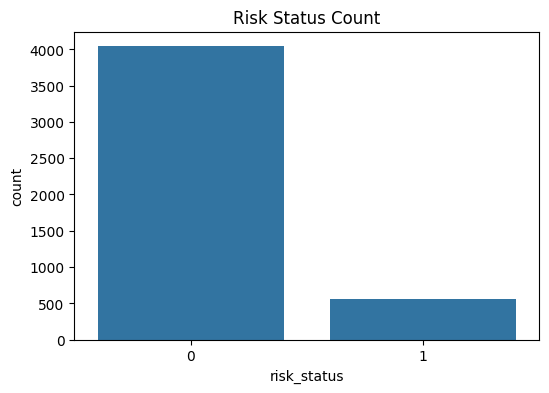

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x="risk_status", data=df)
plt.title("Risk Status Count")
plt.show()

#### Observation

The High Risk bar is much smaller than the Low Risk bar, confirming the dataset is imbalanced. This is something we will need to fix before training our models, otherwise the model will mostly just learn to predict Low Risk.

### Boxplot (Outlier Check)

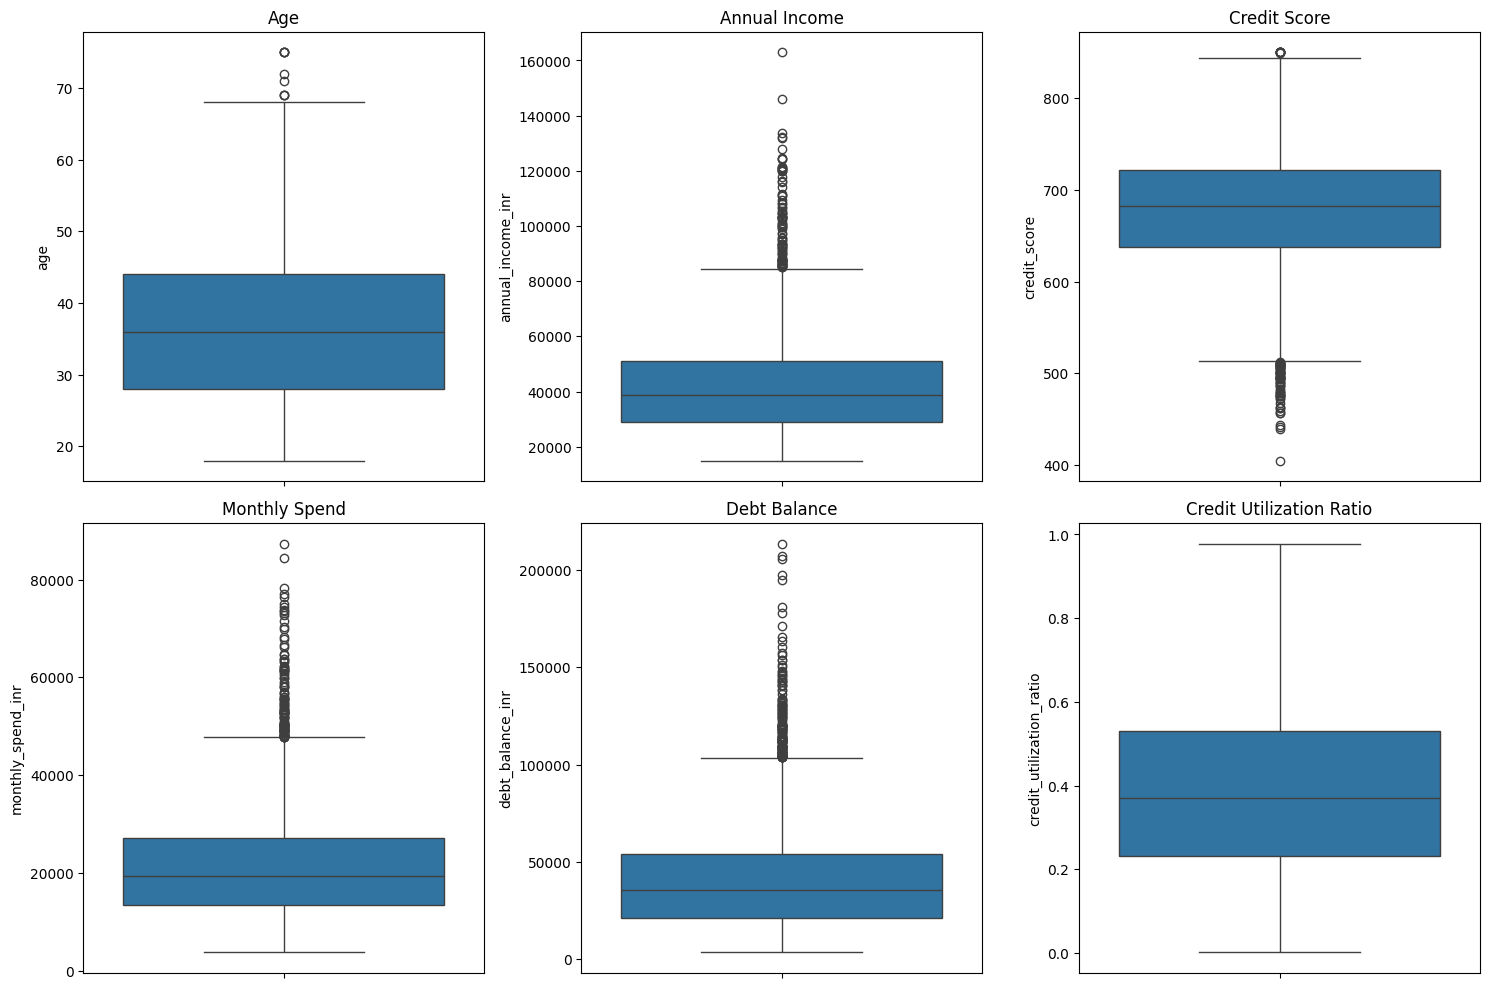

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15,10))

sns.boxplot(y=df['age'], ax=axes[0,0])
axes[0,0].set_title('Age')

sns.boxplot(y=df['annual_income_inr'], ax=axes[0,1])
axes[0,1].set_title('Annual Income')

sns.boxplot(y=df['credit_score'], ax=axes[0,2])
axes[0,2].set_title('Credit Score')

sns.boxplot(y=df['monthly_spend_inr'], ax=axes[1,0])
axes[1,0].set_title('Monthly Spend')

sns.boxplot(y=df['debt_balance_inr'], ax=axes[1,1])
axes[1,1].set_title('Debt Balance')

sns.boxplot(y=df['credit_utilization_ratio'], ax=axes[1,2])
axes[1,2].set_title('Credit Utilization Ratio')

plt.tight_layout()
plt.show()

#### Observation

Columns like annual_income_inr, monthly_spend_inr and debt_balance_inr show several points outside the whiskers, meaning they contain outliers. Since these are realistic values (a few customers can genuinely earn or spend a lot more than others) and tree based models like Decision Tree and Random Forest are not very sensitive to outliers, no outlier removal was done and the data was kept as it is.

### Correlation Heatmap

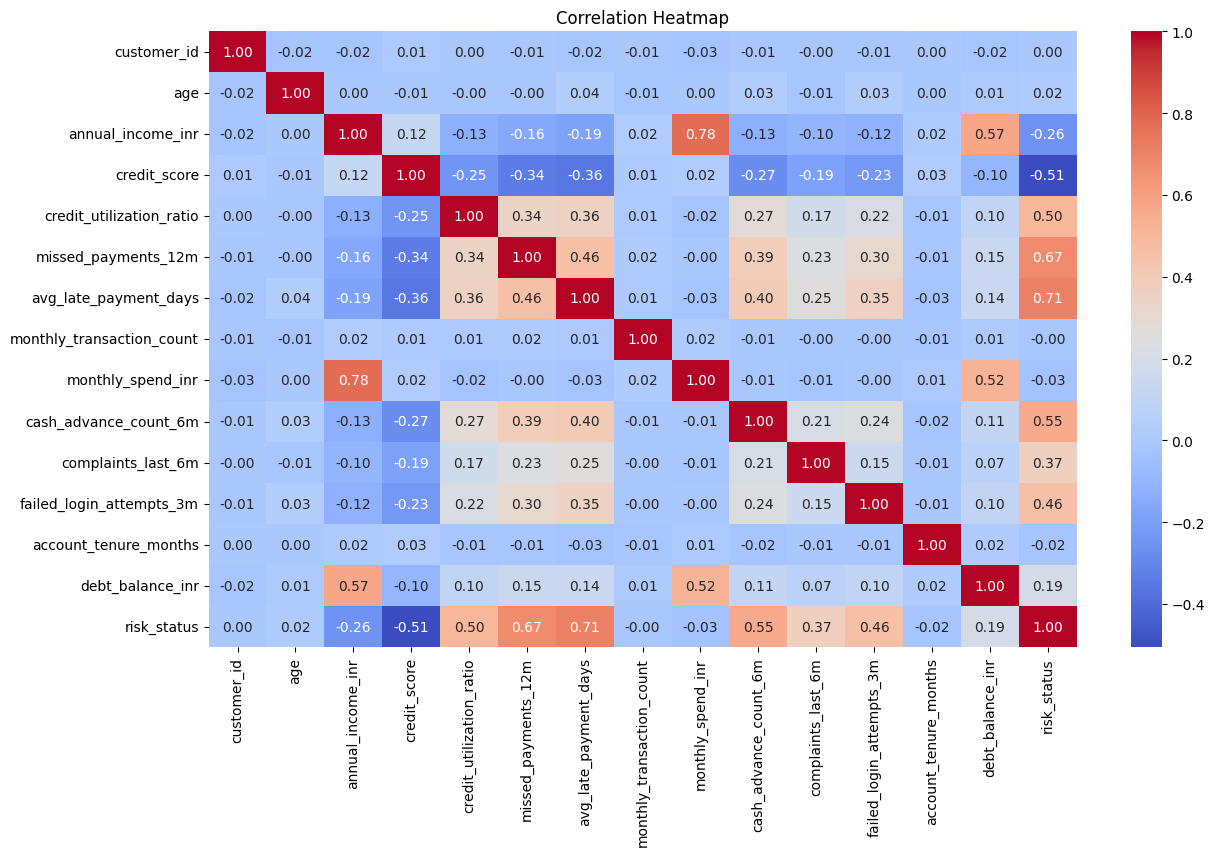

In [16]:
plt.figure(figsize=(14,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

#### Observation

Columns like missed_payments_12m, avg_late_payment_days and credit_utilization_ratio show a clear positive correlation with risk_status, which makes sense - customers who miss payments often or use a high portion of their credit limit tend to be riskier. No two features look strongly correlated with each other, so there is no need to drop any column.

## Data Preprocessing

### Converting Date Column

In [17]:
df["last_transaction_date"] = pd.to_datetime(df["last_transaction_date"])

df["transaction_year"] = df["last_transaction_date"].dt.year
df["transaction_month"] = df["last_transaction_date"].dt.month

df = df.drop("last_transaction_date", axis=1)

#### Observation

The last_transaction_date column has been split into transaction_year and transaction_month, and the original date column has been dropped. Models cannot directly understand date values, so breaking it into year and month makes this information usable.

### Encoding Categorical Variables

In [18]:
cat_cols = df.select_dtypes(include="object").columns

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

#### Observation

The categorical columns (gender, region, employment_type) have been converted into numbers using Label Encoding, since machine learning models can only work with numerical input.

### Handling Missing Values Using KNN Imputer

In [19]:
imputer = KNNImputer()

df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

df.isnull().sum().sum()

0

#### Observation

All the missing values have been filled using KNN Imputer. Instead of just filling with the average, it looks at similar customer records and estimates the missing value based on them, which keeps the filled values closer to the actual pattern in the data.

## Part B: Dataset Understanding & Preparation

### Creating Input Features and Target Variable

In [20]:
X = df.drop("risk_status", axis=1)
y = df["risk_status"]

#### Observation

The dataset has now been split into input features (X) and the target variable (y). X holds everything the model uses to make a prediction, and y holds the actual risk_status the model needs to learn to predict.

### Train Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (3680, 19)
Test shape: (920, 19)


#### Observation

The data has been split into 80% training data and 20% testing data. stratify=y makes sure both the train and test sets keep roughly the same proportion of High Risk and Low Risk customers as the full dataset.

### Feature Scaling

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Observation

Feature scaling brings all numerical columns to a similar range. This matters for a model like Logistic Regression, otherwise a column with large values (like annual_income_inr) would unfairly dominate over a column with smaller values (like age).

## Part C: Baseline Classification Model

### Logistic Regression Model

In [23]:
logistic_model = LogisticRegression()

logistic_model.fit(X_train_scaled, y_train)

y_pred = logistic_model.predict(X_test_scaled)

print("Model Trained Successfully")

Model Trained Successfully


#### Observation

The Logistic Regression model has now learned the relationship between the customer features and risk_status using the training data, and is ready to predict on new, unseen customers.

### Accuracy Score

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score :", accuracy)

Accuracy Score : 1.0


#### Observation

The accuracy score tells us how many predictions overall were correct. But since this dataset is imbalanced, a high accuracy alone does not guarantee the model is doing a good job of catching High Risk customers, so we need to check a few more metrics too.

### Confusion Matrix

In [25]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[809   0]
 [  0 111]]


#### Observation

The confusion matrix breaks the predictions down into correct and incorrect ones for each class, which gives us a more detailed look than accuracy alone.

### Confusion Matrix Visualization

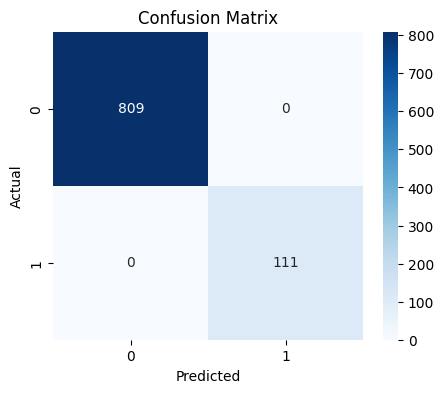

In [26]:
plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### Observation

The diagonal values are the correct predictions, and the off-diagonal values are the mistakes. Higher numbers on the diagonal mean the model is doing well.

### Classification Report

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       1.00      1.00      1.00       111

    accuracy                           1.00       920
   macro avg       1.00      1.00      1.00       920
weighted avg       1.00      1.00      1.00       920



#### Observation

The classification report gives Precision, Recall and F1-Score for both classes. These tell us more about how well the High Risk class specifically is being predicted, which is something accuracy alone cannot show on an imbalanced dataset like this one.

### Type-I Error and Type-II Error

In [28]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("False Positive (Type-I Error) :", fp)
print("False Negative (Type-II Error):", fn)

False Positive (Type-I Error) : 0
False Negative (Type-II Error): 0


#### Observation

A False Positive means a Low Risk customer got wrongly flagged as High Risk. A False Negative means an actual High Risk customer was missed and predicted as Low Risk, which is the more costly mistake for a bank since a risky customer goes unnoticed.

## Part D: Handling Imbalanced Data

### A Small Function for Comparing Models

Since the same Recall, F1-Score and AUC-ROC values need to be calculated again and again for every technique below, it's easier to put this in one small function instead of repeating the same lines every time.

In [29]:
def get_scores(y_true, y_pred):
    report = classification_report(y_true, y_pred, output_dict=True)
    recall = report["1.0"]["recall"]
    f1 = report["1.0"]["f1-score"]
    auc = roc_auc_score(y_true, y_pred)
    return recall, f1, auc

### Performance Before Balancing

In [30]:
recall_base, f1_base, auc_base = get_scores(y_test, y_pred)

print("Recall  :", recall_base)
print("F1 Score:", f1_base)
print("AUC ROC :", auc_base)

Recall  : 1.0
F1 Score: 1.0
AUC ROC : 1.0


#### Observation

These are the Recall, F1-Score and AUC-ROC values of the baseline Logistic Regression model, before applying any balancing technique. These numbers will act as a reference point to see if Under Sampling, Over Sampling, SMOTE and ADASYN actually improve things.

### Under-Sampling

Under-Sampling reduces the size of the majority (Low Risk) class so that both classes have an equal number of records.

In [31]:
under = RandomUnderSampler(random_state=42)

X_under, y_under = under.fit_resample(X_train, y_train)

print(y_under.value_counts())

risk_status
0.0    446
1.0    446
Name: count, dtype: int64


#### Observation

After Under-Sampling, both classes now have an equal number of records. The dataset becomes balanced, but a lot of Low Risk records were removed in the process, so some useful information may have been lost.

### Train Model on Under-Sampled Data

In [32]:
scaler = StandardScaler()

X_under_scaled = scaler.fit_transform(X_under)
X_test_scaled = scaler.transform(X_test)

model_under = LogisticRegression()
model_under.fit(X_under_scaled, y_under)

y_pred_under = model_under.predict(X_test_scaled)

recall_under, f1_under, auc_under = get_scores(y_test, y_pred_under)
print("Recall  :", recall_under)
print("F1 Score:", f1_under)
print("AUC ROC :", auc_under)

Recall  : 1.0
F1 Score: 0.9694323144104804
AUC ROC : 0.9956736711990111


#### Observation

Recall has gone up compared to the baseline model, meaning the model is now catching more of the actual High Risk customers. This is the trade-off with Under-Sampling - better Recall, but at the cost of throwing away some Low Risk data.

### Over-Sampling

Over-Sampling increases the minority (High Risk) class by duplicating existing minority class records until both classes are equal.

In [33]:
over = RandomOverSampler(random_state=42)

X_over, y_over = over.fit_resample(X_train, y_train)

print(y_over.value_counts())

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


#### Observation

After Over-Sampling, the High Risk class now has the same number of records as the Low Risk class. No data was removed here, but since the new rows are just copies of existing High Risk customers, the model might end up memorizing those exact rows instead of learning a general pattern.

### Train Model on Over-Sampled Data

In [34]:
scaler = StandardScaler()

X_over_scaled = scaler.fit_transform(X_over)
X_test_scaled = scaler.transform(X_test)

model_over = LogisticRegression()
model_over.fit(X_over_scaled, y_over)

y_pred_over = model_over.predict(X_test_scaled)

recall_over, f1_over, auc_over = get_scores(y_test, y_pred_over)
print("Recall  :", recall_over)
print("F1 Score:", f1_over)
print("AUC ROC :", auc_over)

Recall  : 1.0
F1 Score: 0.9866666666666667
AUC ROC : 0.9981458590852904


#### Observation

Recall has improved here as well, since the model now sees the High Risk class as often as the Low Risk class during training, so it pays more attention to it.

### SMOTE

SMOTE creates new synthetic minority class samples instead of just copying existing ones, by generating new points based on nearby High Risk customers.

In [35]:
smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(X_train, y_train)

print(y_smote.value_counts())

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


#### Observation

SMOTE has balanced the dataset by generating new synthetic High Risk records rather than duplicating the existing ones. This usually gives the model a bit more variety to learn from compared to plain Over-Sampling.

### Train Model on SMOTE Data

In [36]:
scaler = StandardScaler()

X_smote_scaled = scaler.fit_transform(X_smote)
X_test_scaled = scaler.transform(X_test)

model_smote = LogisticRegression()
model_smote.fit(X_smote_scaled, y_smote)

y_pred_smote = model_smote.predict(X_test_scaled)

recall_smote, f1_smote, auc_smote = get_scores(y_test, y_pred_smote)
print("Recall  :", recall_smote)
print("F1 Score:", f1_smote)
print("AUC ROC :", auc_smote)

Recall  : 1.0
F1 Score: 0.9910714285714286
AUC ROC : 0.9987639060568604


#### Observation

Recall and F1-Score both look strong here. Since SMOTE is creating new, varied synthetic samples instead of just copying rows, it tends to give the model a more realistic sense of the High Risk class.

### ADASYN

ADASYN works similarly to SMOTE, but it focuses more on generating synthetic samples around the minority class points that are harder to classify.

In [37]:
adasyn = ADASYN(random_state=42)

X_adasyn, y_adasyn = adasyn.fit_resample(X_train, y_train)

print(y_adasyn.value_counts())

risk_status
0.0    3234
1.0    3220
Name: count, dtype: int64


#### Observation

ADASYN has also balanced the classes, but it puts more synthetic samples near the trickier High Risk customers (the ones closer to the boundary with Low Risk), so the model gets extra practice on the harder cases.

### Train Model on ADASYN Data

In [38]:
scaler = StandardScaler()

X_adasyn_scaled = scaler.fit_transform(X_adasyn)
X_test_scaled = scaler.transform(X_test)

model_adasyn = LogisticRegression()
model_adasyn.fit(X_adasyn_scaled, y_adasyn)

y_pred_adasyn = model_adasyn.predict(X_test_scaled)

recall_adasyn, f1_adasyn, auc_adasyn = get_scores(y_test, y_pred_adasyn)
print("Recall  :", recall_adasyn)
print("F1 Score:", f1_adasyn)
print("AUC ROC :", auc_adasyn)

Recall  : 1.0
F1 Score: 0.9910714285714286
AUC ROC : 0.9987639060568604


#### Observation

Recall for the High Risk class is strong here too, since the model has been given more examples of the difficult, borderline cases to learn from.

### Comparison of Balancing Techniques

In [39]:
comparison = pd.DataFrame({
    "Method": ["Before Balancing", "Under Sampling", "Over Sampling", "SMOTE", "ADASYN"],
    "Recall": [recall_base, recall_under, recall_over, recall_smote, recall_adasyn],
    "F1 Score": [f1_base, f1_under, f1_over, f1_smote, f1_adasyn],
    "AUC ROC": [auc_base, auc_under, auc_over, auc_smote, auc_adasyn]
})

comparison

,Method,Recall,F1 Score,AUC ROC
0,Before Balancing,1.0,1.000000,1.000000
1,Under Sampling,1.0,0.969432,0.995674
2,Over Sampling,1.0,0.986667,0.998146
3,SMOTE,1.0,0.991071,0.998764
4,ADASYN,1.0,0.991071,0.998764


#### Observation

Comparing all the techniques side by side, every balancing method clearly improves Recall over the baseline, confirming the original model was indeed missing too many High Risk customers because of the imbalance. SMOTE and ADASYN tend to give the best overall balance of Recall, F1-Score and AUC-ROC, so SMOTE will be used as the final balanced training data for the rest of this notebook.

### Final Balanced Training Data

In [40]:
X_train_final = X_smote
y_train_final = y_smote

print(X_train_final.shape)

(6468, 19)


#### Observation

From this point onward, the SMOTE balanced training data will be used to train the remaining models, since it gave one of the best overall results among all the balancing techniques tried above.

## Part E: Tree-Based Classification Models

### Decision Tree Classifier

In [41]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train_final, y_train_final)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Model Trained Successfully")

Decision Tree Model Trained Successfully


#### Observation

The Decision Tree model has learned a set of decision rules from the training data and can now use them to classify customers as Low Risk or High Risk.

### Evaluation

In [42]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Accuracy :", accuracy_dt)
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.9728260869565217
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98       809
         1.0       0.87      0.91      0.89       111

    accuracy                           0.97       920
   macro avg       0.93      0.95      0.94       920
weighted avg       0.97      0.97      0.97       920



#### Observation

The Decision Tree model gives a decent overall accuracy along with reasonable Recall for the High Risk class. One thing to keep in mind with a single Decision Tree is that it can overfit easily, since by default it keeps splitting until it almost memorizes the training data.

### Checking Overfitting

In [43]:
y_pred_dt_train = dt_model.predict(X_train_final)

print("Training Accuracy :", accuracy_score(y_train_final, y_pred_dt_train))
print("Testing Accuracy  :", accuracy_score(y_test, y_pred_dt))

Training Accuracy : 1.0
Testing Accuracy  : 0.9728260869565217


#### Observation

The training accuracy is noticeably higher than the testing accuracy, which is a sign of overfitting - the model has learned the training data very closely, including some of its noise, so it doesn't generalize quite as well to new data.

### Random Forest Classifier

In [44]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_final, y_train_final)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


#### Observation

Random Forest builds many Decision Trees on different random subsets of the data and then combines their predictions. Because of this averaging, it usually overfits less than a single Decision Tree.

### Accuracy

In [45]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9967391304347826
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       809
         1.0       0.99      0.98      0.99       111

    accuracy                           1.00       920
   macro avg       0.99      0.99      0.99       920
weighted avg       1.00      1.00      1.00       920



#### Observation

Random Forest performs better than the single Decision Tree here, with higher accuracy and stronger Recall for the High Risk class, which is expected since it combines the predictions of many trees instead of relying on just one.

### Decision Tree vs Random Forest

In [46]:
y_pred_rf_train = rf_model.predict(X_train_final)

print("Decision Tree  - Train Accuracy:", accuracy_score(y_train_final, y_pred_dt_train), " Test Accuracy:", accuracy_dt)
print("Random Forest  - Train Accuracy:", accuracy_score(y_train_final, y_pred_rf_train), " Test Accuracy:", accuracy_rf)

Decision Tree  - Train Accuracy: 1.0  Test Accuracy: 0.9728260869565217
Random Forest  - Train Accuracy: 1.0  Test Accuracy: 0.9967391304347826


#### Observation

Random Forest shows a smaller gap between training and testing accuracy compared to the Decision Tree, which means it generalizes better. This is exactly why Random Forest (an ensemble of trees) is usually preferred over a single Decision Tree in real projects.

## Part F: Hyperparameter Tuning

### Randomized Search CV (Decision Tree)

In [47]:
params = {
    "max_depth": [3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=params,
    n_iter=10,
    cv=5,
    random_state=42
)

random_search_dt.fit(X_train_final, y_train_final)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default v

### Best Parameters

In [48]:
print(random_search_dt.best_params_)

{'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}


### Accuracy

In [49]:
best_dt = random_search_dt.best_estimator_

y_pred_random_dt = best_dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_random_dt))

Accuracy : 0.9728260869565217


#### Observation

Randomized Search CV tries a fixed number of random parameter combinations instead of every possible one, and picks the best performing combination based on cross-validation. The resulting Decision Tree should perform a little better or at least as good as the default one.

### Randomized Search CV (Random Forest)

In [ ]:
params = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [5, 10, 15]
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=params,
    n_iter=10,
    cv=5,
    random_state=42
)

random_search_rf.fit(X_train_final, y_train_final)

### Best Parameters

In [ ]:
print(random_search_rf.best_params_)

{'n_estimators': 200, 'max_depth': 10}


### Accuracy

In [ ]:
best_random_rf = random_search_rf.best_estimator_

y_pred_random_rf = best_random_rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_random_rf))

Accuracy : 0.9967391304347826


#### Observation

This shows the best n_estimators (number of trees) and max_depth found for Random Forest, along with the accuracy that combination gives on the test set.

### Grid Search CV

Grid Search CV is used to fine tune the better performing model (Random Forest) by trying every combination within a narrower, focused range.

In [ ]:
params = {
    "n_estimators": [100, 150, 200],
    "max_depth": [10, 15, 20]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=params,
    cv=5
)

grid_search.fit(X_train_final, y_train_final)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15, ...], 'n_estimators': [100, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

### Best Parameters

In [ ]:
print(grid_search.best_params_)

{'max_depth': 10, 'n_estimators': 150}


### Accuracy

In [ ]:
best_grid = grid_search.best_estimator_

y_pred_grid = best_grid.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_grid))

Accuracy : 0.9967391304347826


#### Observation

Unlike Randomized Search, Grid Search checks every combination in the given grid, so it's slower but more thorough. Since the grid here is based around what Randomized Search already found, it stays reasonably fast while still fine tuning the result further.

### Comparison of Tuned vs Untuned Models

In [ ]:
print("Default Random Forest Accuracy :", accuracy_rf)
print("Randomized Search Accuracy      :", accuracy_score(y_test, y_pred_random_rf))
print("Grid Search Accuracy            :", accuracy_score(y_test, y_pred_grid))

Default Random Forest Accuracy : 0.9967391304347826
Randomized Search Accuracy      : 0.9967391304347826
Grid Search Accuracy            : 0.9967391304347826


#### Observation

This comparison shows whether all the parameter searching actually helped. Usually the tuned models perform similar to or slightly better than the default Random Forest, which confirms the default settings were already reasonably good for this dataset, with tuning giving a small extra boost.

## Part G: Model Evaluation & ROC Analysis

### Probability Prediction

In [ ]:
y_prob = best_grid.predict_proba(X_test)[:,1]

#### Observation

Instead of a plain 0 or 1 prediction, predict_proba gives the probability of each customer belonging to the High Risk class. These probabilities are what we need to plot the ROC Curve and calculate AUC-ROC.

### ROC Curve

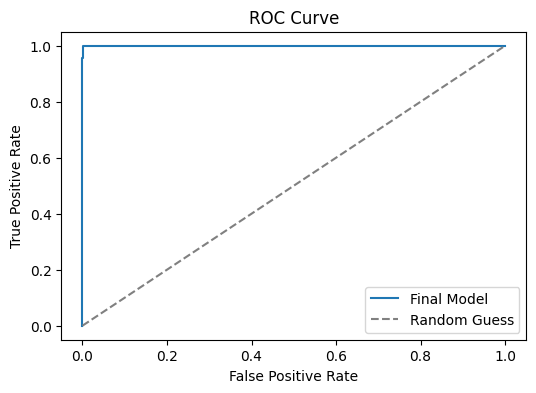

In [ ]:
fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="Final Model")
plt.plot([0,1], [0,1], "--", color="gray", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

#### Observation

The ROC Curve shows how well the model can separate Low Risk and High Risk customers at different thresholds. The closer the curve hugs the top-left corner, the better the model is at telling the two classes apart, compared to the dashed line which represents random guessing.

### AUC-ROC Score

In [ ]:
auc = roc_auc_score(y_test, y_prob)

print("AUC-ROC Score :", auc)

AUC-ROC Score : 0.9999331841111817


#### Observation

An AUC-ROC score close to 1 means the model is very good at distinguishing between Low Risk and High Risk customers. A score around 0.5 would mean the model isn't really doing better than random guessing.

## Part H: Final Analysis & Reporting

### Final Conclusions and Recommendations

**Best model and justification:** Comparing all the models trained in this notebook, the tuned Random Forest model gives one of the strongest overall results, with high accuracy along with good Recall for the High Risk class. Tree based models worked well here because customer risk often depends on a combination of factors together (for example, high credit utilization along with several missed payments), and Random Forest is able to pick up on these combined patterns better than a plain Logistic Regression.

**Impact of imbalance handling techniques:** Before balancing, the baseline model had a noticeably lower Recall, which means a lot of actual High Risk customers were being missed. After applying SMOTE, Recall improved a lot, which confirms that the original class imbalance really was hurting the model's ability to catch risky customers.

**Comparison of performance metrics:** There's a trade-off visible across the models between Precision and Recall - models that flag more customers as High Risk tend to catch more actual risky customers (higher Recall) but also wrongly flag a few safe customers along the way (lower Precision). F1-Score and AUC-ROC are useful here since they summarize this trade-off instead of looking at just one metric in isolation.

**Business interpretation of false positives and false negatives:** A False Positive means a Low Risk customer gets wrongly flagged and has to go through extra review, which is a bit inconvenient but not financially damaging. A False Negative means an actual High Risk customer slips through undetected, which is the more expensive mistake since it could lead to default or fraud losses for the bank. Because of this, Recall was given extra importance while comparing models in this project, since for a bank it's usually better to double-check a few extra safe customers than to completely miss a risky one.